
### Imports and global setup

This notebook constructs a synthetic local galaxy catalog for use in downstream transient simulations.
Standard scientific Python libraries are imported, and a fixed random seed is set to ensure reproducibility.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


### Global parameters

We define the size of the local Universe and the total number of galaxies in the synthetic catalog.
The Universe is assumed to be local, Euclidean, and non-evolving.


In [2]:
# Universe parameters
R_MAX = 300.0          # Mpc
N_GALAXIES = 50_000    # size of galaxy catalog


### Galaxy positions

Galaxy positions are drawn uniformly in three-dimensional volume within a spherical region of radius 300 Mpc.
The radial distribution scales as r ∝ u^{1/3} to ensure constant number density.


In [3]:
u = np.random.uniform(0, 1, N_GALAXIES)
r = R_MAX * u**(1/3)

theta = np.arccos(1 - 2 * np.random.uniform(0, 1, N_GALAXIES))
phi = 2 * np.pi * np.random.uniform(0, 1, N_GALAXIES)

x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)


## Stellar Mass Distribution

Galaxy stellar masses are drawn from a Schechter-like mass function.  
This produces a realistic spread of galaxy masses while keeping the model simple.

The distribution has:

- Many low-mass galaxies  
- Fewer high-mass galaxies  
- A sharp drop above a characteristic mass scale  

Masses are sampled between \(10^{9.5}\) and \(10^{12}\) solar masses using rejection sampling in log-space.

The lower limit of \(10^{9.5}\,M_\odot\) matches the mass-completeness limit of local Universe surveys such as SDSS (Baldry et al. 2006), ensuring the population is directly comparable to observational benchmarks used in the quiescent fraction calibration.

In [4]:
distance = np.sqrt(x**2 + y**2 + z**2)


### Stellar mass distribution

Galaxy stellar masses are drawn from a Schechter-like mass function.
This provides a realistic mass distribution while remaining a simple toy model.


In [5]:
alpha_m = -1.3
M_star_char = 1e10      # solar masses
M_min = 10**9.5         # ~3.16e9 solar masses — matches mass-complete surveys (e.g. SDSS)
M_max = 1e12

def sample_schechter_mass(N, alpha, M_star, M_min, M_max):
    M = []
    while len(M) < N:
        M_trial = 10**np.random.uniform(np.log10(M_min), np.log10(M_max))
        y = np.random.uniform(0, 1)
        phi = (M_trial / M_star)**alpha * np.exp(-M_trial / M_star)
        phi_max = (M_min / M_star)**alpha
        if y < phi / phi_max:
            M.append(M_trial)
    return np.array(M)

M_star = sample_schechter_mass(
    N_GALAXIES, alpha_m, M_star_char, M_min, M_max
)

### Quiescent galaxy assignment

Each galaxy is assigned a probability of being quiescent that depends on stellar mass, following a logistic function motivated by Baldry et al. (2006).

The transition mass M₀ = 10^9.8 M☉ and slope k = 2.0 are tuned to reproduce an overall quiescent fraction of ~40% for a mass-complete sample above 10^9.5 M☉, consistent with observed values in the local Universe (Baldry et al. 2006).

In [6]:
logM = np.log10(M_star)

# 1. Mass-dependent quenching probability
# Logistic form motivated by Baldry et al. (2006).
# M0=9.8, k=2.0 tuned to reproduce ~40% quiescent fraction
# for a mass-complete sample above 10^9.5 Msun in the local Universe.
def quiescent_fraction(logM, M0=9.8, k=2.0):
    return 1 / (1 + np.exp(-k * (logM - M0)))

f_Q = quiescent_fraction(logM)
is_quiescent = np.random.rand(len(logM)) < f_Q

# 2. Star-forming main sequence (local Universe)
logSFR_MS = 0.8 * (logM - 10) - 0.3
scatter = np.random.normal(0, 0.3, N_GALAXIES)

logSFR = logSFR_MS + scatter

# 3. Quenched population suppressed by 2 dex
logSFR[is_quiescent] -= 2.0

SFR = 10**logSFR

# 4. sSFR-based classification (observational definition)
log_sSFR = logSFR - logM
gal_type = np.where(log_sSFR < -11, "Q", "SF")

# Store
galaxies = pd.DataFrame({
    "M_star": M_star,
    "logM": logM,
    "SFR": SFR,
    "log_sSFR": log_sSFR,
    "type": gal_type
})

### Star-formation rates

Star-forming galaxies are assigned star-formation rates following a mass-dependent main sequence with scatter.
Quiescent galaxies have their star-formation rates suppressed relative to the main sequence.


## Galaxy Luminosities

Galaxy luminosities are drawn independently from a Schechter luminosity function. This produces a realistic distribution in which faint galaxies are common and very bright galaxies are rare.

The model assumes a single photometric band and does not include dust or redshift evolution. This keeps the treatment simple and consistent with a local, static universe.

Luminosities are sampled over a defined range using rejection sampling in log-space. The Schechter form ensures:

- A power-law rise toward low luminosities  
- An exponential cutoff at high luminosities  
- A characteristic luminosity scale  

This provides a physically motivated luminosity distribution for the synthetic galaxy population while remaining computationally straightforward.



In [7]:
alpha_L = -1.1
L_star = 1.0
L_min = 1e-3
L_max = 50.0

def sample_schechter_L(N, alpha, L_star, L_min, L_max):
    L = []
    while len(L) < N:
        L_trial = 10**np.random.uniform(np.log10(L_min), np.log10(L_max))
        y = np.random.uniform(0, 1)
        phi = (L_trial / L_star)**alpha * np.exp(-L_trial / L_star)
        phi_max = (L_min / L_star)**alpha
        if y < phi / phi_max:
            L.append(L_trial)
    return np.array(L)

L = sample_schechter_L(
    N_GALAXIES, alpha_L, L_star, L_min, L_max
)


## Galaxy Catalogue Assembly

All galaxy properties are combined into a single structured table.

Each entry contains:

- 3D position (x, y, z)  
- Distance from the origin  
- Stellar mass  
- Star-formation rate  
- Quiescent classification  
- Luminosity  

This catalogue represents the complete synthetic galaxy population within 300 Mpc.

It serves as the base dataset for subsequent notebooks, where transient events are assigned, detected, and analysed.


In [8]:
galaxies = pd.DataFrame({
    "x": x,
    "y": y,
    "z": z,
    "distance": distance,
    "M_star": M_star,
    "SFR": SFR,
    "is_quiescent": is_quiescent,
    "L": L
})


### Validation: Mass–SFR Relation

This plot shows stellar mass against star-formation rate for the synthetic galaxies.

The x-axis shows log10 stellar mass in solar masses.  
The y-axis shows log10 star-formation rate in solar masses per year.

Star-forming galaxies follow a clear trend with mass, forming a main sequence with some scatter. Quiescent galaxies appear at much lower star-formation rates.

So Basically Low mass galaxies are str and high mass are quiescent


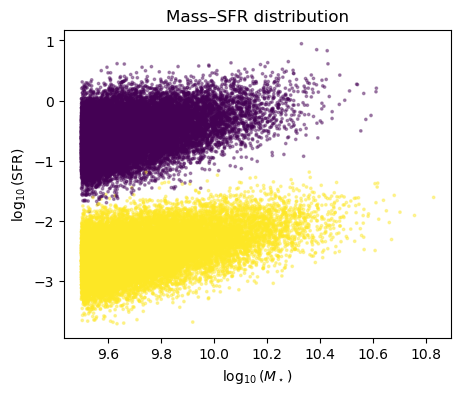

In [9]:
plt.figure(figsize=(5, 4))
plt.scatter(np.log10(galaxies["M_star"]),
            np.log10(galaxies["SFR"] + 1e-6),
            c=galaxies["is_quiescent"],
            s=3,
            alpha=0.4)
plt.xlabel(r"$\log_{10}(M_\star)$")
plt.ylabel(r"$\log_{10}(\mathrm{SFR})$")
plt.title("Mass–SFR distribution")
plt.show()


In [10]:
print(np.mean(gal_type == "Q"))


0.45726


### Validation: spatial and luminosity distribution

Purple points indicate star-forming galaxies following a mass-dependent star-formation main sequence.
Yellow points indicate quiescent galaxies with suppressed star-formation rates.


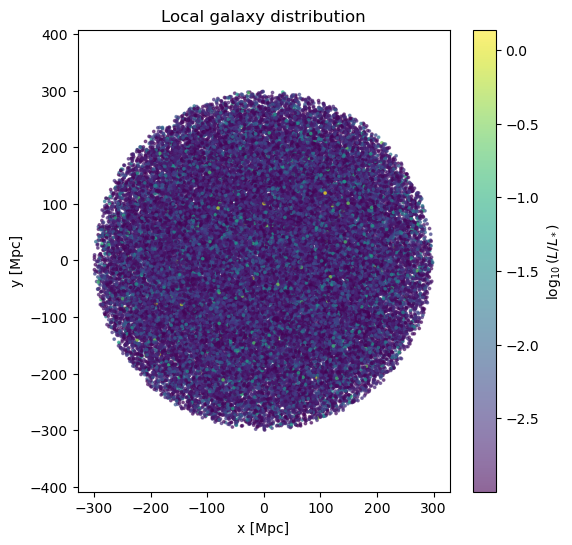

In [11]:
plt.figure(figsize=(6, 6))
sc = plt.scatter(galaxies["x"], galaxies["y"],
                 c=np.log10(galaxies["L"]),
                 s=3,
                 cmap="viridis",
                 alpha=0.6)
plt.xlabel("x [Mpc]")
plt.ylabel("y [Mpc]")
plt.colorbar(sc, label=r"$\log_{10}(L/L_*)$")
plt.title("Local galaxy distribution")
plt.axis("equal")
plt.show()


### Interpretation of the local galaxy distribution

Each point represents a galaxy projected onto the x–y plane and coloured by luminosity.
Most galaxies appear faint because the Schechter luminosity function is steep at low luminosities, meaning low-luminosity galaxies are far more numerous than bright ones.
Bright galaxies are therefore rare and visually outnumbered, even though they are distributed uniformly across the volume.
No spatial clustering is included by design.


In [12]:
galaxies.to_csv("galaxy_catalog.csv", index=False)


### Stellar Mass Distribution

This histogram shows the stellar mass function of the galaxy population.

The distribution shows a rise toward low masses and decline exponentially at high masses, consistent with a Schechter-like mass function.


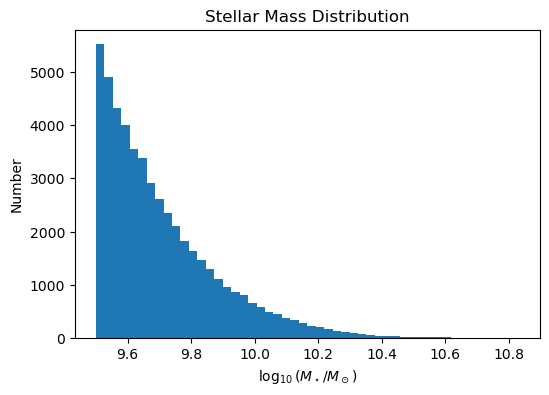

In [13]:
plt.figure(figsize=(6,4))
plt.hist(np.log10(galaxies["M_star"]), bins=50)
plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel("Number")
plt.title("Stellar Mass Distribution")
plt.show()



### Radial Distribution

This histogram shows the number of galaxies as a function of distance from the centre of the 300 Mpc sphere.

The x-axis shows radius in Mpc.  
The y-axis shows the number of galaxies in each radial bin.

The number of galaxies increases toward larger radii because the volume of spherical shells increases with radius.

This confirms that galaxies are distributed uniformly in three-dimensional space.



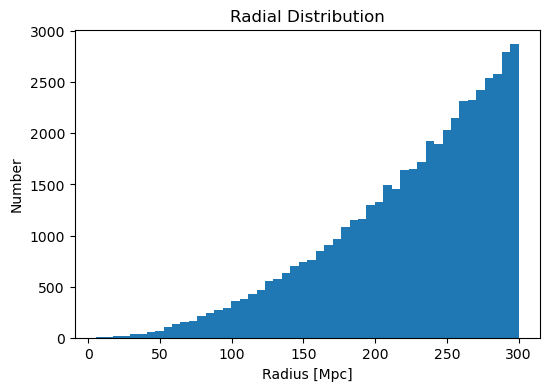

In [14]:
radii = np.sqrt(
    galaxies["x"]**2 +
    galaxies["y"]**2 +
    galaxies["z"]**2
)

plt.figure(figsize=(6,4))
plt.hist(radii, bins=50)
plt.xlabel("Radius [Mpc]")
plt.ylabel("Number")
plt.title("Radial Distribution")
plt.show()


### Luminosity Distribution

This histogram shows the distribution of galaxy luminosities.

The x-axis shows log10 luminosity.  
The y-axis shows the number of galaxies in each bin.

Most galaxies are faint, while only a small number are very bright. This matches the expected behaviour of a Schechter luminosity function, where faint galaxies are common and bright galaxies are rare.


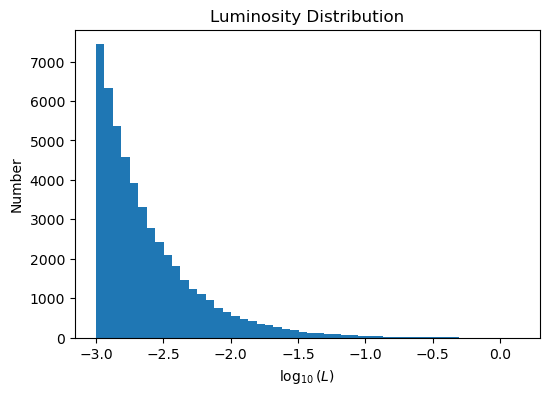

In [15]:
plt.figure(figsize=(6,4))

plt.hist(
    np.log10(galaxies["L"]),
    bins=50
)

plt.xlabel(r"$\log_{10}(L)$")
plt.ylabel("Number")
plt.title("Luminosity Distribution")

plt.show()


### Mass-Dependent Quenching

This plot shows the fraction of quiescent galaxies as a function of stellar mass.

The quiescent fraction increases with mass, reproducing the observed trend that more massive galaxies are more likely to be quenched.

To avoid artificial spikes at high mass, bins with very small numbers of galaxies are excluded.


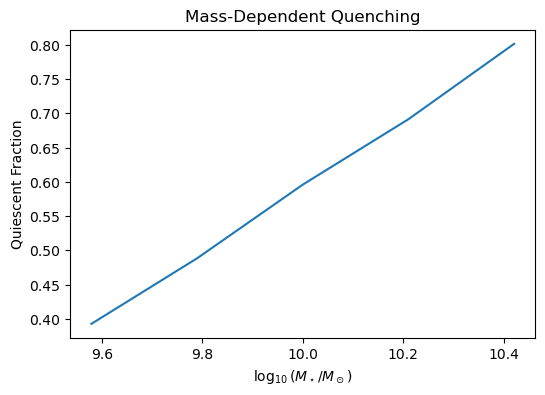

In [16]:
bins = np.linspace(8, 12, 20)
mass_log = np.log10(galaxies["M_star"])

frac = []
centers = []

min_count = 50  

for i in range(len(bins)-1):
    mask = (mass_log > bins[i]) & (mass_log <= bins[i+1])
    if mask.sum() > min_count:
        frac.append(galaxies["is_quiescent"][mask].mean())
        centers.append((bins[i] + bins[i+1]) / 2)

plt.figure(figsize=(6,4))
plt.plot(centers, frac)
plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$")
plt.ylabel("Quiescent Fraction")
plt.title("Mass-Dependent Quenching")
plt.show()
